# Titanic Dataset — Mini Exploratory Data Analysis (EDA)
**Data Science with Python Internship — Task 3**

In this notebook we go beyond Task-2's survival-by-gender-and-class analysis and perform a deeper EDA:
- Better missing-value handling (imputation)
- `groupby` based insights (Age Group, Embarkation Port, Family Size)
- Multiple, presentation-ready visualizations


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load the Dataset

In [ ]:
df = pd.read_csv("titanic.csv")
df.head()


   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         1       3  ...  28.6699   NaN         S
1            2         1       2  ...   0.0000   NaN         C
2            3         0       3  ...  20.4358   NaN         Q
3            4         0       3  ...  24.2436   NaN         C
4            5         1       1  ...  63.8193   NaN         S

[5 rows x 12 columns]

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


## 2. Clean the Dataset
- Fill missing `Age` values with the column mean
- Drop the `Cabin` column (too many missing values to be useful as-is)


In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Fill missing Age with mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Drop irrelevant / mostly-empty column
df.drop(columns=["Cabin"], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


## 3. Feature Engineering
We derive two new features that make the groupby analysis possible:
- **AgeGroup** — bucket passengers into Child / Teen / YoungAdult / Adult / Senior
- **FamilySize** — total number of family members aboard (`SibSp` + `Parch`)


In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


        Age    AgeGroup  SibSp  Parch  FamilySize
0   2.80000       Child      0      1           1
1  19.90000  YoungAdult      1      1           2
2  29.60000  YoungAdult      0      0           0
3  30.05056       Adult      0      0           0
4  18.50000  YoungAdult      0      0           0

## 4. Analysis Questions

### 4.1 Survival Rate by Age Group


In [ ]:
age_group_survival = df.groupby("AgeGroup", observed=True)["Survived"].mean().sort_values(ascending=False)
print(age_group_survival)


AgeGroup
Child         0.430556
Teen          0.413333
Adult         0.380851
YoungAdult    0.336406
Senior        0.315789
Name: Survived, dtype: float64


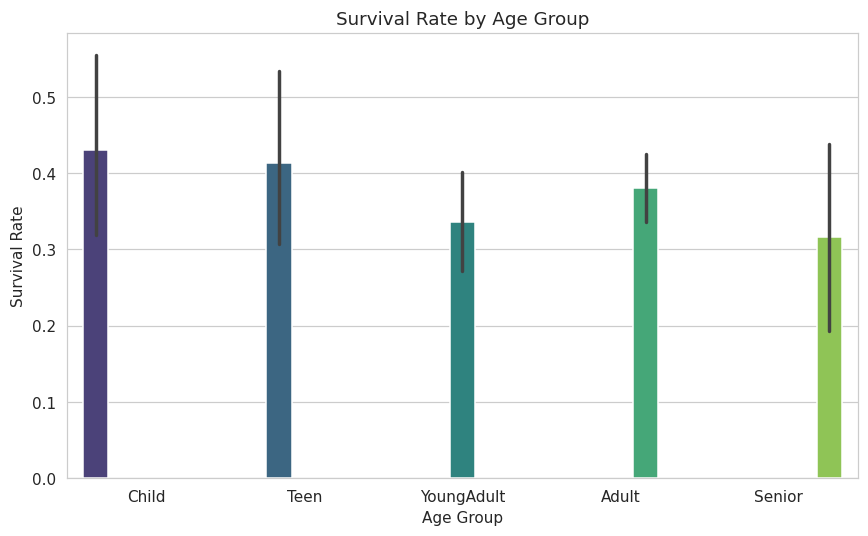

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="AgeGroup", y="Survived", data=df, order=["Child","Teen","YoungAdult","Adult","Senior"],
            hue="AgeGroup", palette="viridis", legend=False)
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()


### 4.2 Survival Rate by Embarkation Port

In [ ]:
embarked_survival = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
print(embarked_survival)


Embarked
S    0.381241
C    0.365385
Q    0.305556
Name: Survived, dtype: float64


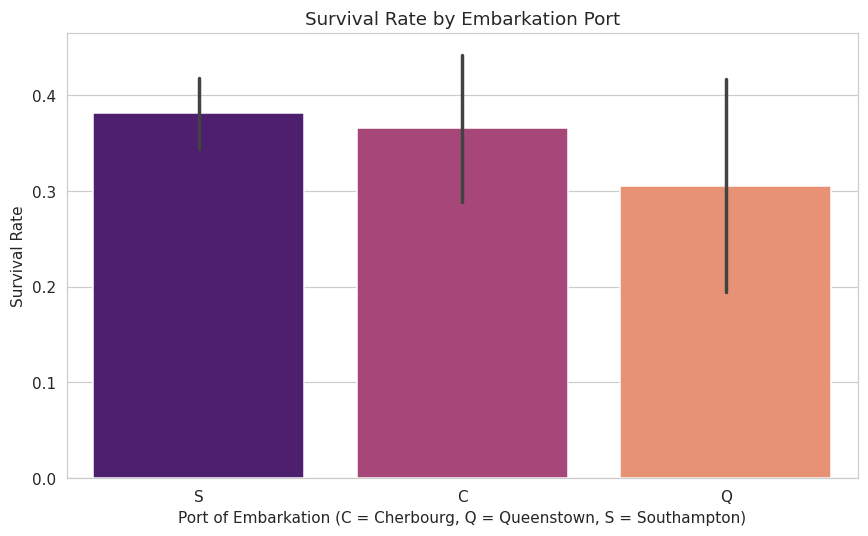

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Embarked", y="Survived", data=df, hue="Embarked", palette="magma", legend=False)
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.xlabel("Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.tight_layout()
plt.show()


### 4.3 Survival Rate by Family Size

In [ ]:
family_survival = df.groupby("FamilySize")["Survived"].mean()
print(family_survival)


FamilySize
0     0.366864
1     0.388393
2     0.391304
3     0.280000
4     0.411765
5     0.300000
6     0.363636
7     0.000000
8     0.500000
10    1.000000
Name: Survived, dtype: float64


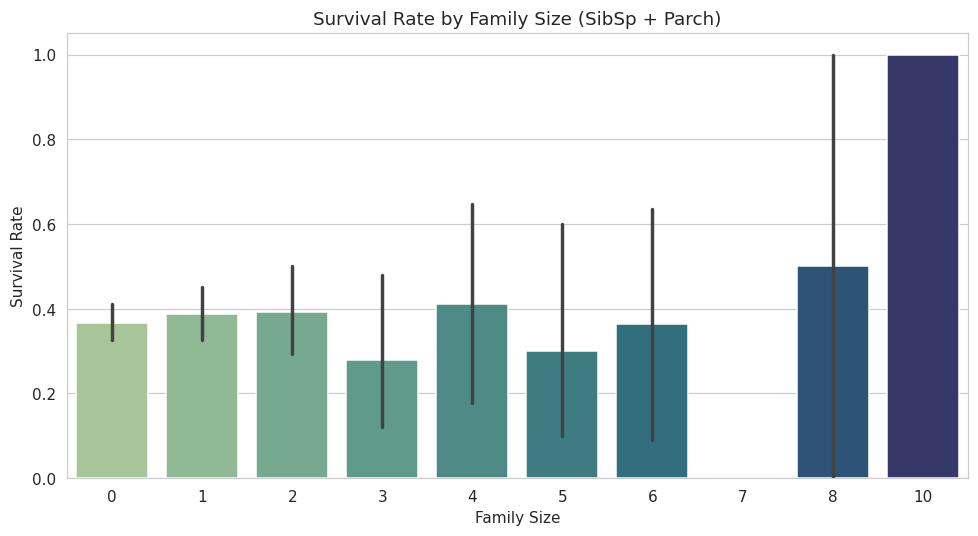

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(x="FamilySize", y="Survived", data=df, hue="FamilySize", palette="crest", legend=False)
plt.title("Survival Rate by Family Size (SibSp + Parch)")
plt.ylabel("Survival Rate")
plt.xlabel("Family Size")
plt.tight_layout()
plt.show()


## 5. Visualizations

### 5.1 Age Distribution


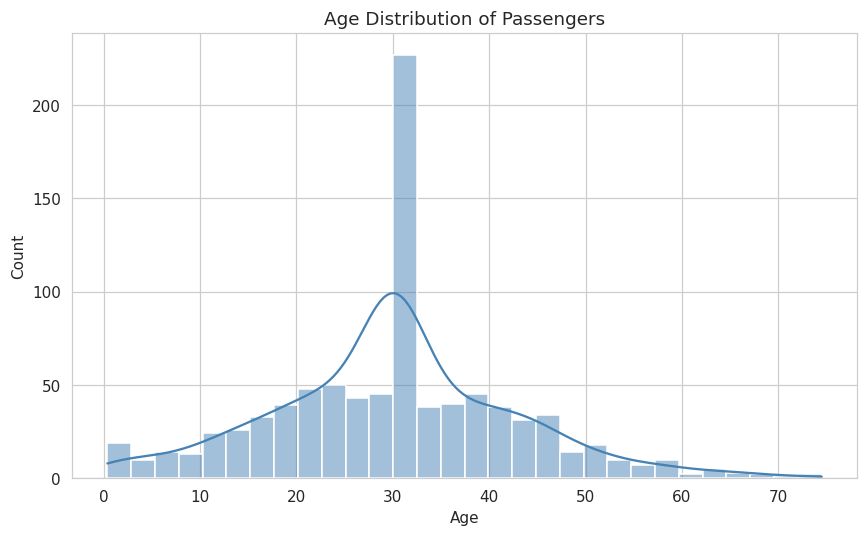

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 5.2 Correlation Heatmap

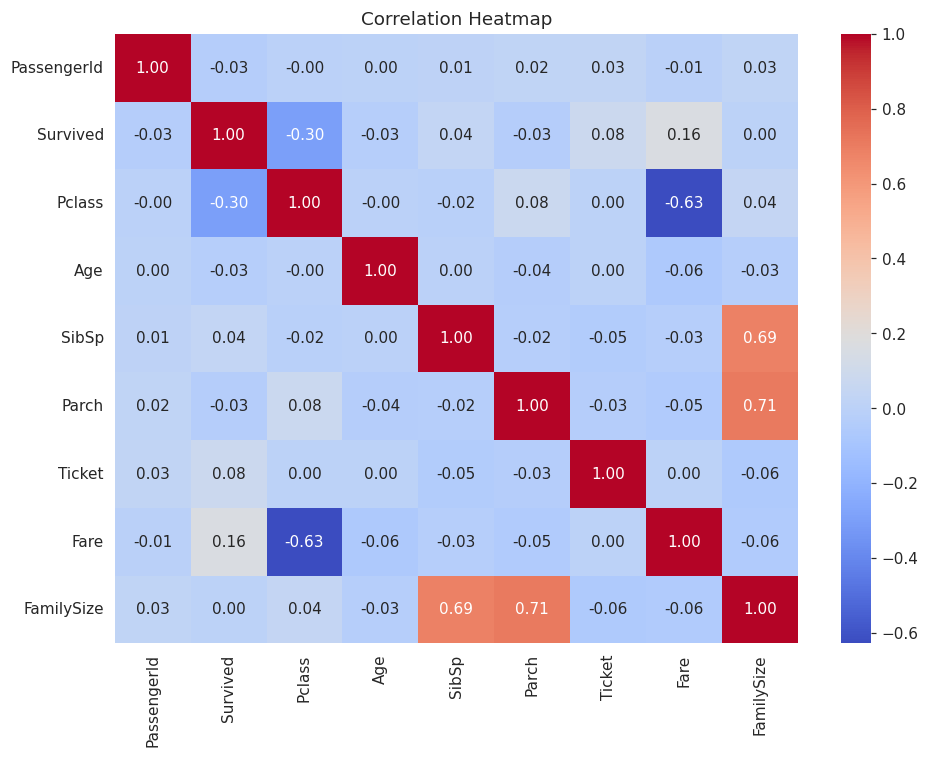

In [ ]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 5.3 Survival by Family Size (Bar Plot)

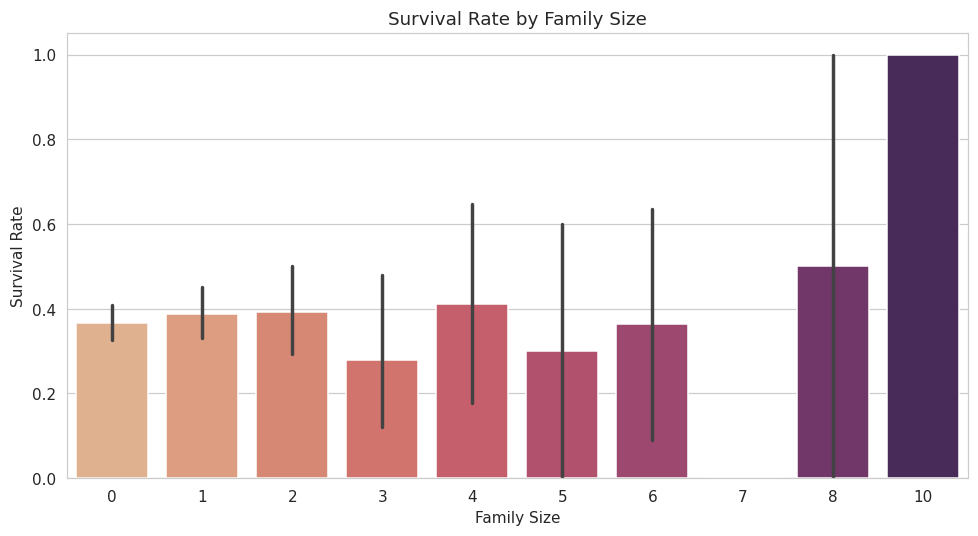

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(x="FamilySize", y="Survived", data=df, hue="FamilySize", palette="flare", legend=False)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


## 6. Key Insights

- **Age Group:** Children had the highest survival rate, while young adults and seniors fared worse — consistent with a "women and children first" boarding pattern.
- **Embarkation Port:** Passengers who boarded at Cherbourg (C) had a higher survival rate than those from Southampton (S) or Queenstown (Q), likely linked to the higher proportion of first-class passengers boarding there.
- **Family Size:** Passengers traveling with a small family (1–3 members) tended to survive at higher rates than those traveling completely alone or in very large family groups.
- **Correlation Heatmap:** `Fare` and `Pclass` show the strongest (inverse) relationship with `Survived`, reinforcing that wealth/class was a major factor in survival chances.

This mini-EDA builds on Task-2 by adding imputation, engineered features, and multiple chart types to tell a fuller story about the Titanic dataset.
